In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp
import skimage.transform as skimt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

from helpers import *

device: cuda


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugi

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

missing keys: 0
unexpected keys: 0


In [4]:
from scipy import ndimage

def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        # convert inversion grid coordinates to image coordinates
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            # for doublet, flip the original equilibrium to match the new grid orientation
             eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                            coord_eval_pos, order=2, mode="nearest",
                                                            prefilter=True).reshape(Nz, Nr)
        else:
            # evaluate original fbte input on the prescribed inversion grid
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                                coord_eval_pos, order=2, mode="nearest",
                                                                prefilter=True).reshape(Nz, Nr)
    return eqs

In [5]:
import scipy.io as scio
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import os 

# select samples to be used for normalization procedure
samples_idxs = np.arange(0,10000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# load forward model
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_max = A_sparse.max()  # capture ORIGINAL max BEFORE normalization (used to rescale physical y_tomo)
A_sparse /= A_max  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T

0.0 1.0 (100, 4800)


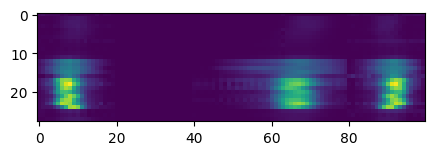

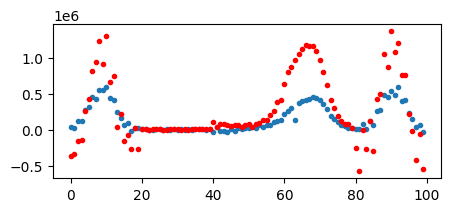

In [6]:
# shot number
shots = [85270, 88458, 88794, 88764, 88772, 88767, 88798, 88997]
shot = shots[0]# 85270


exp_data = scio.loadmat(f'experimental_data/shot_data_{shot}.mat')['data'][0, 0] # singlet
psi=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=False)

plt.figure(figsize=(5, 2))
plt.imshow(np.abs(exp_data["measurements"]))
#plt.yticks([0,10,20], labels=[str(exp_data["measurements_times"].flatten()[0]), str(exp_data["measurements_times"].flatten()[10]), str(exp_data["measurements_times"].flatten()[20])])
plt.show()
plt.figure(figsize=(5, 2))
plt.plot(exp_data["measurements"][10,:], '.')
plt.plot(exp_data["measurements"][26,:], 'r.')

In [7]:
exp_data["measurements"].shape[0]

28

In [8]:
exp_idxs=np.arange(0,100)[::10]

exp_idxs = exp_idxs[exp_idxs < exp_data["measurements"].shape[0]] 

## Finer time grid: fluctuation analysis

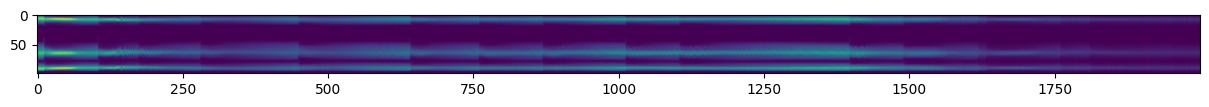

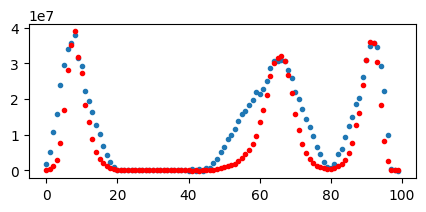

In [10]:
# shot number
shot = 88767

exp_data = scio.loadmat(f'experimental_data/shot_data_full_88767_finetimegrid.mat')['data'][0, 0] # singlet
psi=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=False)

plt.figure(figsize=(15, 15))
plt.imshow(np.abs(exp_data["measurements"]).T)
#plt.yticks([0,10,20], labels=[str(exp_data["measurements_times"].flatten()[0]), str(exp_data["measurements_times"].flatten()[10]), str(exp_data["measurements_times"].flatten()[20])])
plt.show()
plt.figure(figsize=(5, 2))
plt.plot(exp_data["measurements"][10,:], '.')
plt.plot(exp_data["measurements"][26,:], 'r.')

In [13]:
exp_data["measurements_times"].flatten()[-1]

np.float64(1.100000023841858)

In [50]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

# --- key parameter: window in ms → convert to samples ---
window_ms = 8.0          # adjust: ~5-20x fluctuation period
dt_ms     = 0.1          # 0.1 ms per sample

sigma_samples = (window_ms / dt_ms) / 6.0  # σ = window/6 → ±3σ spans window

measurements = exp_data["measurements"]  # shape (1000, 100)

# Gaussian background: smooth along time axis (axis=0)
background = gaussian_filter1d(
    measurements, sigma=sigma_samples, axis=0, mode="reflect"
)

# Background-subtracted signal, ready for tomographic inversion
fluctuations = measurements - background  # shape (1000, 100)

# Optional: relative fluctuations δε/⟨ε⟩ (avoids edge bias)
rel_fluctuations = np.divide(
    fluctuations, background,
    out=np.zeros_like(fluctuations),
    where=background > 0
)

# Each row is one time slice → invert fluctuations[t, :]
signal_to_invert = fluctuations  # or rel_fluctuations

# Pre-injection reference (first 5ms, before gas arrives)
background_ref = measurements[1000:1050, :].mean(axis=0, keepdims=True)
signal_to_invert = measurements - background_ref  # invert this
signal_to_invert = background_ref

In [51]:
signal_to_invert.shape

(1, 100)

### Invert SXR measurements (baseline profile)

In [55]:
# define tomographic data
#exp_idxs=np.arange(0,100)[::2][1:]
exp_idxs=np.arange(900,2000)[::100]

exp_idxs = exp_idxs[exp_idxs < signal_to_invert.shape[0]] # ensure selected indices are within bounds

# store params used for inversions
params_invs = np.zeros(3) # store best anisotropic parameters for each sample

im_maps = []

# define grid of anisotropic parameters for tuning  
anis_params_grid = np.logspace(-4, 0, 13)

posterior_tomo = torch.zeros((1, 100, 1, H, W), dtype=torch.float32, device=device)
idx = 0

# use core mask or not
use_core_mask = True

for exp_idx in range(1):

    if use_core_mask:
        core_mask = np.zeros((H, W), dtype=bool)
        core_mask[psi[exp_idx]<0.0005] = True
        row_sums = np.sum(core_mask, axis=1)
        xpt_position = 60+np.argmin(row_sums[60:])
        core_mask[xpt_position:, :] = False

    good_channels = exp_data['good_channels'].flatten() - 1
    y_tomo = np.array(signal_to_invert.flatten() * exp_data["etendues"].flatten() * 4 * np.pi) / A_max # rescale to match normalized A
    y_tomo = y_tomo[good_channels] # remove faulty channels

    #sigma_err = 0.02
    anis_param = 1e-2
    reg_param = 1e-1
    with_positivity_constraint = True

    # estimate noise and scale 
    print(y_tomo_train.shape, y_tomo.shape)
    print(good_channels.shape)
    bool_good_channels = np.zeros(y_tomo_train.shape[1], dtype=bool)
    bool_good_channels[good_channels] = True
    alpha, y_closest = compute_normalization_coefficient(torch.from_numpy(y_tomo.reshape(1, -1)).to(device=device, dtype=torch.float32), y_tomo_train[:, bool_good_channels])
    print(f"Computed normalization coefficient alpha: {alpha:.4f}")

    y_tomo_rescaled = y_tomo / alpha
    sigma_y_tomo = 0.25 # set to average reasonable noise value

    # # ------------------------------------------------------------------
    # # Define functionals with noisy tomo data
    # # ------------------------------------------------------------------
    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo_rescaled,
        sigma_err=sigma_y_tomo,
        geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy())[good_channels, :],
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx],
        sampling=0.0125,
        matrix_based_impl=True,
    )
    # ------------------------------------------------------------------
    # Tune anisotropic parameter via CV (blind to ground truth)
    # ------------------------------------------------------------------
    anis_param_data = hyper_tune.anis_param_tuning(
        f, g,
        reg_param=reg_param,
        tuning_techniques=["CV_full"],
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=core_mask,
        cv_strategy=["random"],
        anis_params=anis_params_grid,
        plot=False,
    )
    best_anis_idx   = np.argmin(anis_param_data["CV_full_random"][1, :])
    best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
    # ------------------------------------------------------------------
    # Redefine regularization functional with tuned alpha
    # ------------------------------------------------------------------
    params_invs[0] = alpha
    params_invs[1] = best_anis_param
    params_invs[2] = sigma_y_tomo
    print(f"Best anisotropic parameter (CV): {best_anis_param:.4e}")
    g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)

    im_map = bcomp.compute_MAP(
        f, g, reg_param,
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=core_mask,
        show_progress=False,
    ) * alpha

    x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

    im_maps.append(x_map)

        # diffpir 
    posterior_tomo[idx], tomo_residuals, diffusion_process = sample_posterior_diffpir(
        model=model,
        schedule=schedule,
        A=A_tomo[bool_good_channels, :],
        y=torch.from_numpy(y_tomo_rescaled).to(device=device, dtype=torch.float32),
        image_shape=(1, H, W),
        num_samples=100,
        num_inference_steps=250,
        zeta=0.8,
        sigma_y=sigma_y_tomo,
        lambda_=100,   # 300 for normalize_data=False
        clip_range=None,
    )

    idx += 1

torch.Size([10000, 100]) (99,)
(99,)
Computed normalization coefficient alpha: 17275289600.0000
Tuning regularization parameter: 5-fold cross validation (`CV_full`)

Best anisotropic parameter (CV): 1.0000e-02


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [ ]:
# save to .npy files the im_maps, posterior_tomo, and params_tcv_mask_sigma025
np.save("im_maps_core_mask_sigma025_shot2_background.npy", np.array([im_map.cpu().numpy() for im_map in im_maps]))
np.save("posterior_tomo_core_mask_sigma025_shot2_background.npy", posterior_tomo.cpu().numpy())

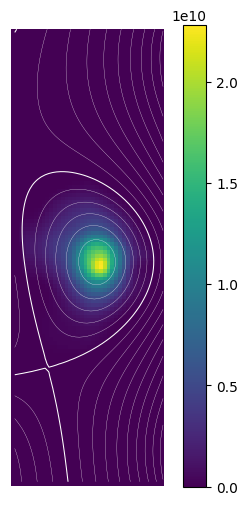

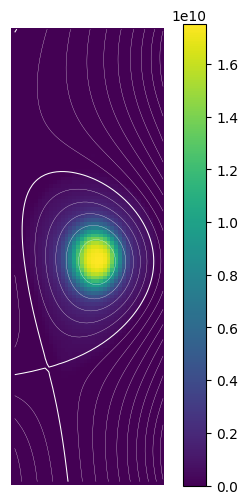

In [63]:
tomo_plots.plot_profile(
    im_map,
    figsize=(4,6),
    contour_image=psi[1000],
    colorbar=True,
    )
plt.show()

tomo_plots.plot_profile(
    posterior_tomo[0, :, 0, :, :].cpu().numpy().mean(axis=0)*alpha,
    contour_image=psi[1000],
    colorbar=True,
    figsize=(4,6),
    )
plt.show()



In [ ]:
tomo_plots.plot_profile(
    posterior_tomo[0, :, 0, :, :].cpu().numpy(),
    title="Shot {}".format(shot),
    figsize=(10, 5),
    ncols=5,
    contour_images=[psi[iidx] for iidx in exp_idxs[30:50]],
    colorbar=True,
    )

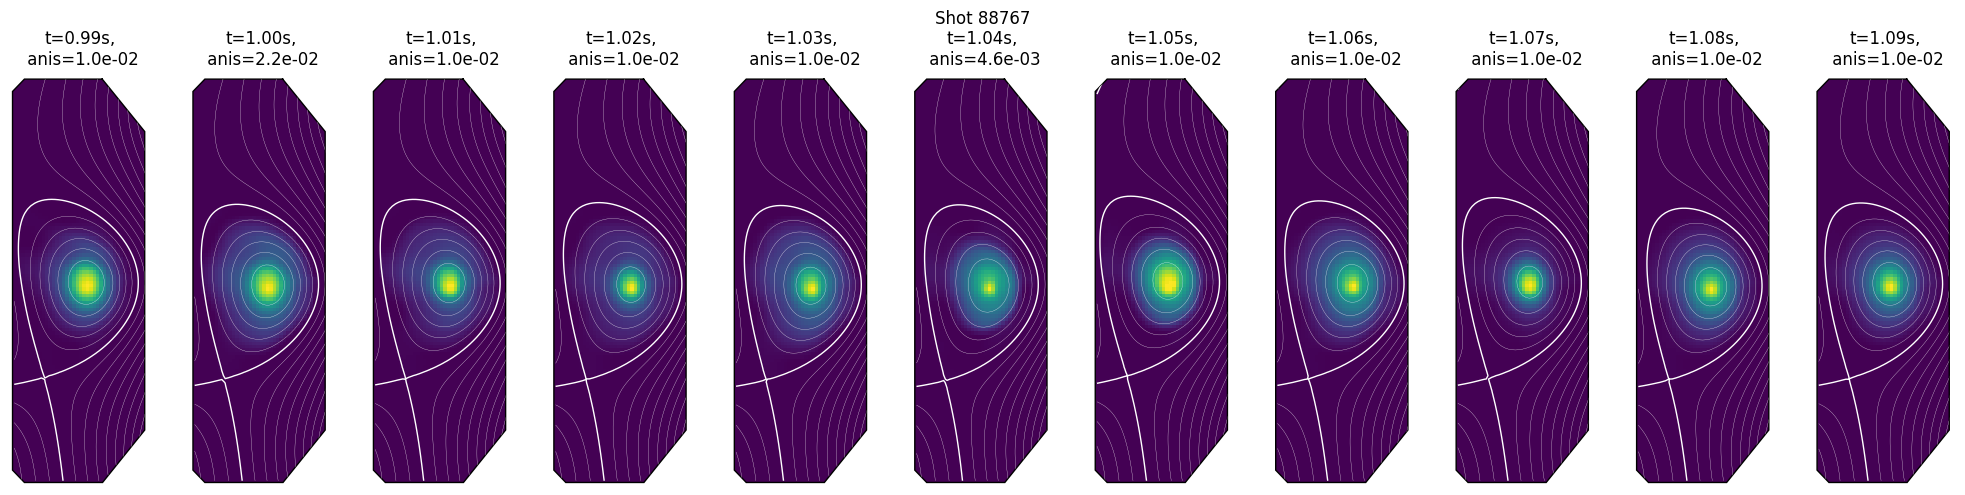

In [26]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------


summary = torch.stack([
    x_map_[0, 0].cpu() for x_map_ in im_maps[::1]
])

params_plot = np.zeros(2000)
for ien, iidx in enumerate(exp_idxs):
    params_plot[iidx] = params_invs[ien,1]
#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[::1]))])
show_samples(
    summary,
    titles=["t={:.2f}s,\n anis={:.1e}".format(exp_data["measurements_times"].flatten()[iidx], params_plot[iidx]) for iidx in exp_idxs[::1]],
    title="Shot {}".format(shot),
    ncols=len(im_maps[::1]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[::1]],
    colorbar=False,
)

In [22]:
exp_idxs[::1]

array([ 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900])

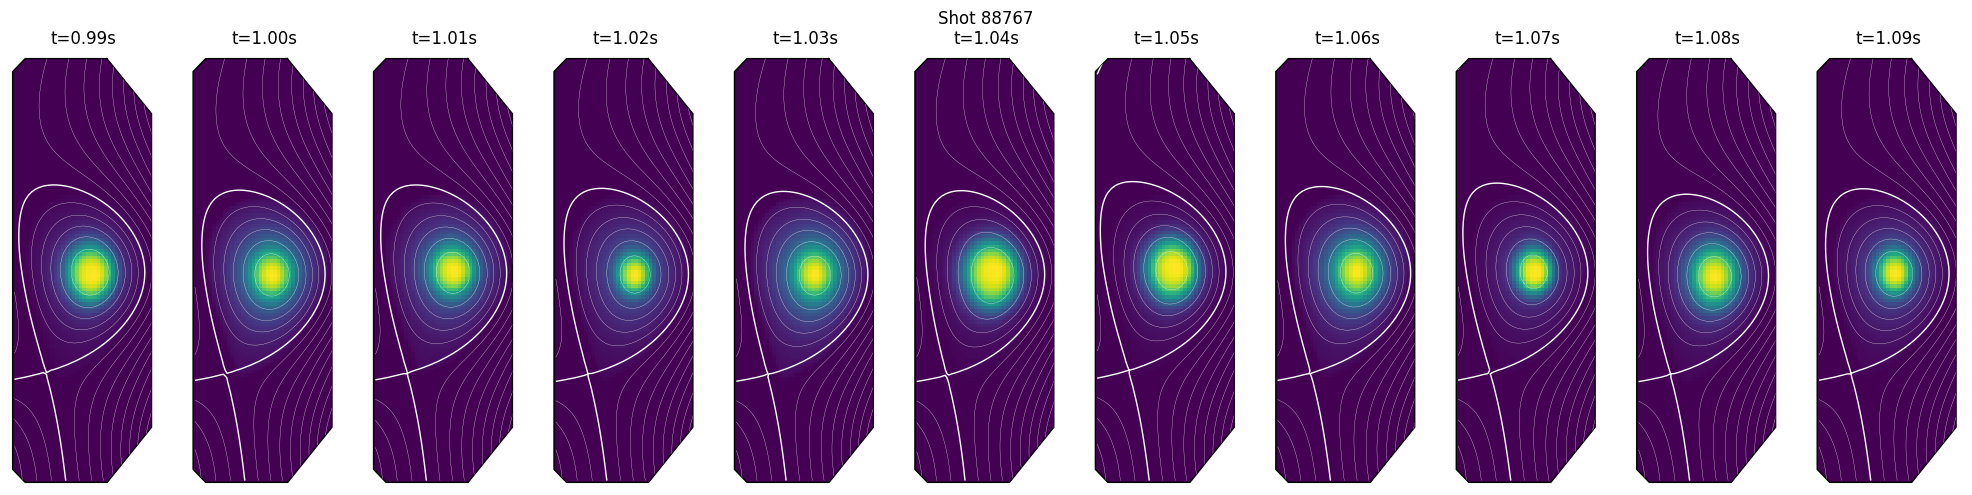

In [18]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
# plot posterior means from posterior_tomo

# show diffpir samples

post_mean = posterior_tomo.mean(dim=1)
idxs_ptm = np.arange(0, post_mean.shape[0], 1)
summary = torch.stack([
    post_mean[ii, 0].cpu() for ii in idxs_ptm])

show_samples(
    summary,
    titles=["t={:.2f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs],
    title="Shot {}".format(shot),
    ncols=len(im_maps),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs],
    colorbar=False,
    vmin=0
)

In [ ]:
# save to .npy files the im_maps, posterior_tomo, and params_tcv_mask_sigma025
# np.save("im_maps_core_mask_sigma025_shot2.npy", np.array([im_map.cpu().numpy() for im_map in im_maps]))
# np.save("posterior_tomo_core_mask_sigma025_shot2.npy", posterior_tomo.cpu().numpy())
# np.save("params_core_mask_sigma025_shot2.npy", params_invs)
# np.save("inv_times_core_mask_sigma025_shot2.npy", exp_data["measurements_times"].flatten()[exp_idxs])

## Invert SXR measurements (fluctuations)

In [44]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp

# define tomographic data
#exp_idxs=np.arange(0,100)[::2][1:]
exp_idxs=np.arange(1000,2000)[::10]

exp_idxs = exp_idxs[exp_idxs < signal_to_invert.shape[0]] # ensure selected indices are within bounds

im_maps = []

for exp_idx in exp_idxs:

    good_channels = exp_data['good_channels'].flatten() - 1
    y_tomo = np.array(signal_to_invert[exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max # rescale to match normalized A
    y_tomo = y_tomo[good_channels] # remove faulty channels
    #y_tomo = torch.from_numpy(y_tomo).to(device=device, dtype=torch.float32)

    sigma_err = 0.02
    anis_param = 1e-2
    reg_param = 1e1
    with_positivity_constraint = True

    scaling_factor = np.max(np.abs(y_tomo))

    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo/scaling_factor,
        sigma_err=sigma_err,
        geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy())[good_channels, :],
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx],
        sampling=0.0125,
        matrix_based_impl=True,
    )

    im_map = bcomp.compute_MAP(
        f, g, reg_param,
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=None,
        show_progress=False,
    ) * scaling_factor

    x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

    im_maps.append(x_map)


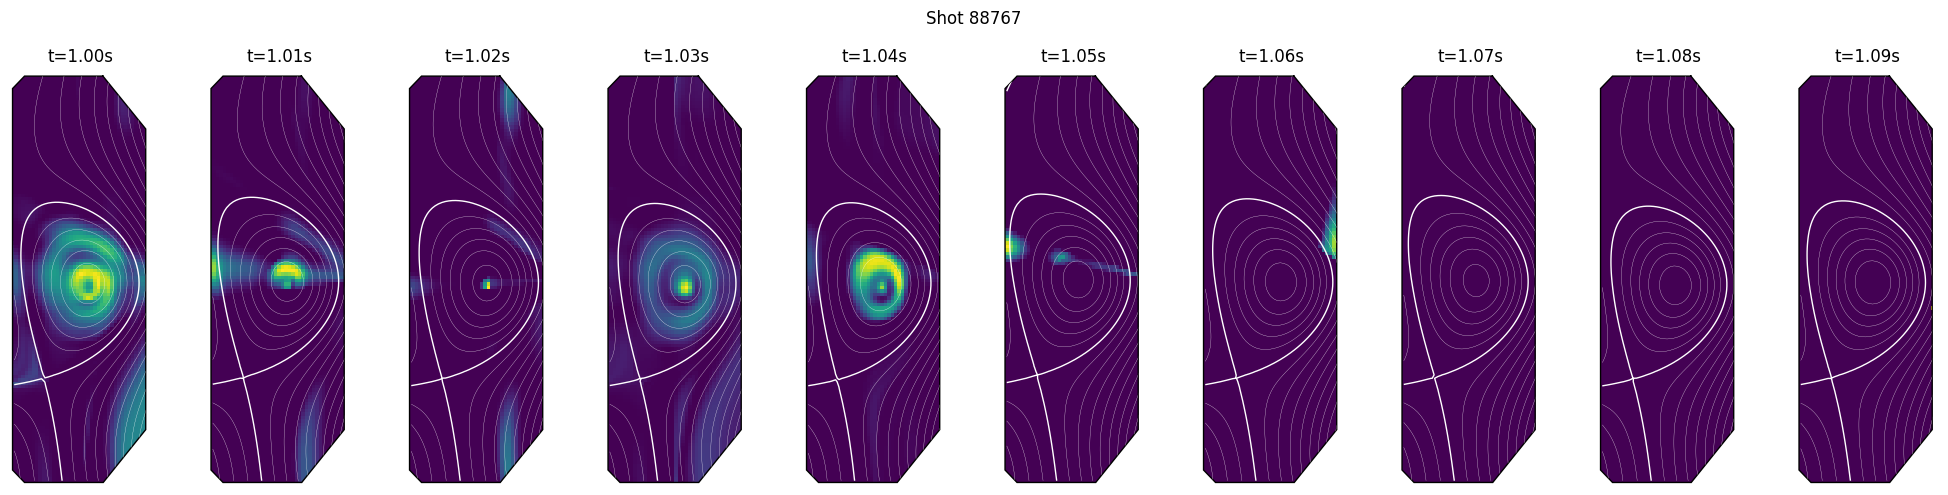

In [45]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

tpids=np.arange(30,40, dtype=int)

summary = torch.stack([
    x_map_[0, 0].cpu() for x_map_ in im_maps[::10]
])

#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[::10]))])
show_samples(
    summary,
    titles=["t={:.2f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[::10]],
    title="Shot {}".format(shot),
    ncols=len(im_maps[::10]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[::10]],
    colorbar=False,
)

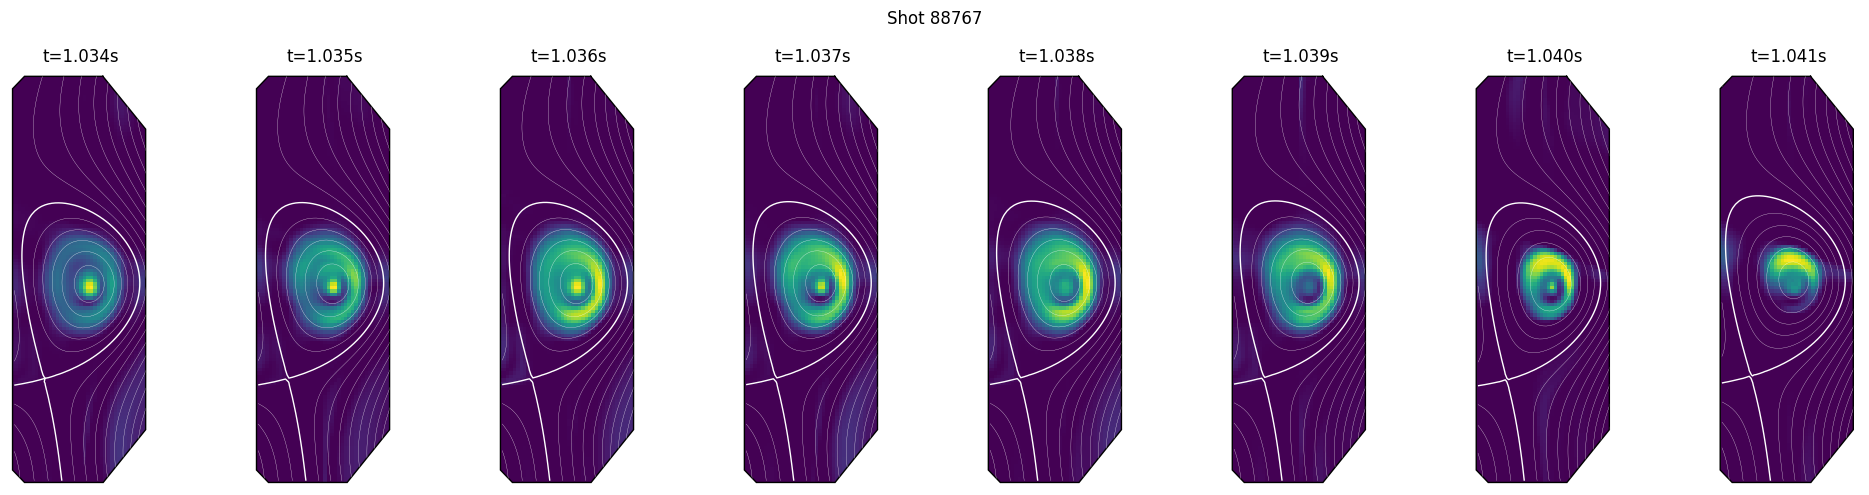

In [48]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

tpids=np.arange(30,40, dtype=int)

summary = torch.stack([
    x_map_[0, 0].cpu() for x_map_ in im_maps[34:42]
])

#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[34:42]))])
show_samples(
    summary,
    titles=["t={:.3f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[34:42]],
    title="Shot {}".format(shot),
    ncols=len(im_maps[34:42]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[34:42]],
    colorbar=False,
)

In [33]:
tpids

array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39])

In [38]:
im_maps[[2,3]]

TypeError: list indices must be integers or slices, not list

In [ ]:
exp_idxs=np.arange(1000,2000)[::10][35:45]

exp_idxs = exp_idxs[exp_idxs < signal_to_invert.shape[0]] # ensure selected indices are within bounds

# store params used for inversions
params_invs = np.zeros((len(exp_idxs), 3)) # store best anisotropic parameters for each sample

im_maps = []

# define grid of anisotropic parameters for tuning  
anis_params_grid = np.logspace(-4, 0, 13)

posterior_tomo = torch.zeros((len(exp_idxs), 100, 1, H, W), dtype=torch.float32, device=device)
idx = 0

# use core mask or not
use_core_mask = True

for exp_idx in exp_idxs:

    if use_core_mask:
        core_mask = np.zeros((H, W), dtype=bool)
        core_mask[psi[exp_idx]<0.0005] = True
        row_sums = np.sum(core_mask, axis=1)
        xpt_position = 60+np.argmin(row_sums[60:])
        core_mask[xpt_position:, :] = False

    good_channels = exp_data['good_channels'].flatten() - 1
    y_tomo = np.array(signal_to_invert[exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max # rescale to match normalized A
    y_tomo = y_tomo[good_channels] # remove faulty channels

    #sigma_err = 0.02
    anis_param = 1e-2
    reg_param = 1e-1
    with_positivity_constraint = True

    # estimate noise and scale 
    print(y_tomo_train.shape, y_tomo.shape)
    print(good_channels.shape)
    bool_good_channels = np.zeros(y_tomo_train.shape[1], dtype=bool)
    bool_good_channels[good_channels] = True
    alpha, y_closest = compute_normalization_coefficient(torch.from_numpy(y_tomo.reshape(1, -1)).to(device=device, dtype=torch.float32), y_tomo_train[:, bool_good_channels])
    print(f"Computed normalization coefficient alpha: {alpha:.4f}")

    y_tomo_rescaled = y_tomo / alpha
    sigma_y_tomo = 0.25 # set to average reasonable noise value

    # ------------------------------------------------------------------
    # Define functionals with noisy tomo data
    # ------------------------------------------------------------------
    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo_rescaled,
        sigma_err=sigma_y_tomo,
        geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy())[good_channels, :],
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx],
        sampling=0.0125,
        matrix_based_impl=True,
    )
    # ------------------------------------------------------------------
    # Tune anisotropic parameter via CV (blind to ground truth)
    # ------------------------------------------------------------------
    anis_param_data = hyper_tune.anis_param_tuning(
        f, g,
        reg_param=reg_param,
        tuning_techniques=["CV_full"],
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=tcv_mask if not use_core_mask else core_mask,
        cv_strategy=["random"],
        anis_params=anis_params_grid,
        plot=False,
    )
    best_anis_idx   = np.argmin(anis_param_data["CV_full_random"][1, :])
    best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
    # ------------------------------------------------------------------
    # Redefine regularization functional with tuned alpha
    # ------------------------------------------------------------------
    params_invs[idx, 0] = alpha
    params_invs[idx, 1] = best_anis_param
    params_invs[idx, 2] = sigma_y_tomo
    print(f"Best anisotropic parameter (CV): {best_anis_param:.4e}")
    g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)

    im_map = bcomp.compute_MAP(
        f, g, reg_param,
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=tcv_mask if not use_core_mask else core_mask,
        show_progress=False,
    ) * alpha

    x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

    im_maps.append(x_map)

        # diffpir 
    posterior_tomo[idx], tomo_residuals, diffusion_process = sample_posterior_diffpir(
        model=model,
        schedule=schedule,
        A=A_tomo[bool_good_channels, :],
        y=torch.from_numpy(y_tomo_rescaled).to(device=device, dtype=torch.float32),
        image_shape=(1, H, W),
        num_samples=100,
        num_inference_steps=250,
        zeta=0.8,
        sigma_y=sigma_y_tomo,
        lambda_=100,   # 300 for normalize_data=False
        clip_range=None,
    )

    idx += 1

torch.Size([10000, 100]) (99,)
(99,)
Computed normalization coefficient alpha: 4520942592.0000
Tuning regularization parameter: 5-fold cross validation (`CV_full`)



KeyboardInterrupt: 

In [ ]:
# save to .npy files the im_maps, posterior_tomo, and params_tcv_mask_sigma025
# np.save("im_maps_core_mask_sigma025_shot2_fluctuations.npy", np.array([im_map.cpu().numpy() for im_map in im_maps]))
# np.save("posterior_tomo_core_mask_sigma025_shot2_fluctuations.npy", posterior_tomo.cpu().numpy())
# np.save("params_core_mask_sigma025_shot2_fluctuations.npy", params_invs)
# np.save("inv_times_core_mask_sigma025_shot2_fluctuations.npy", exp_data["measurements_times"].flatten()[exp_idxs])

# Plot reconstructions

In [ ]:
signal_to_invert.shape

(1000, 100)

In [63]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp

# define tomographic data
#exp_idxs=np.arange(0,100)[::2][1:]
exp_idxs=np.arange(0,1000)[::10]

exp_idxs = exp_idxs[exp_idxs < signal_to_invert.shape[0]] # ensure selected indices are within bounds

im_maps = []

for exp_idx in exp_idxs:

    good_channels = exp_data['good_channels'].flatten() - 1
    y_tomo = np.array(measurements[exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max # rescale to match normalized A
    y_tomo = y_tomo[good_channels] # remove faulty channels
    #y_tomo = torch.from_numpy(y_tomo).to(device=device, dtype=torch.float32)

    sigma_err = 0.02
    anis_param = 1e-2
    reg_param = 1e1
    with_positivity_constraint = True

    scaling_factor = np.max(np.abs(y_tomo))

    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo/scaling_factor,
        sigma_err=sigma_err,
        geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy())[good_channels, :],
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx],
        sampling=0.0125,
        matrix_based_impl=True,
    )

    im_map = bcomp.compute_MAP(
        f, g, reg_param,
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=None,
        show_progress=False,
    ) * scaling_factor

    x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

    im_maps.append(x_map)


KeyboardInterrupt: 

In [64]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp

# define tomographic data
#exp_idxs=np.arange(0,100)[::2][1:]
exp_idxs=np.arange(0,1000)[::10]

exp_idxs = exp_idxs[exp_idxs < signal_to_invert.shape[0]] # ensure selected indices are within bounds

im_maps = []

for exp_idx in exp_idxs:

    good_channels = exp_data['good_channels'].flatten() - 1
    y_tomo = np.array(signal_to_invert[exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max # rescale to match normalized A
    y_tomo = y_tomo[good_channels] # remove faulty channels
    #y_tomo = torch.from_numpy(y_tomo).to(device=device, dtype=torch.float32)

    sigma_err = 0.02
    anis_param = 1e-2
    reg_param = 1e1
    with_positivity_constraint = True

    scaling_factor = np.max(np.abs(y_tomo))

    f = fct_def._DataFidelityFunctional(
        dim_shape=(1, H, W),
        noisy_tomo_data=y_tomo/scaling_factor,
        sigma_err=sigma_err,
        geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy())[good_channels, :],
    )
    g = AnisDiffusionOp(
        dim_shape=(1, H, W),
        alpha=anis_param,
        diff_method_struct_tens="fd",
        freezing_arr=psi[exp_idx],
        sampling=0.0125,
        matrix_based_impl=True,
    )

    im_map = bcomp.compute_MAP(
        f, g, reg_param,
        with_pos_constraint=with_positivity_constraint,
        clipping_mask=None,
        show_progress=False,
    ) * scaling_factor

    x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

    im_maps.append(x_map)


KeyboardInterrupt: 

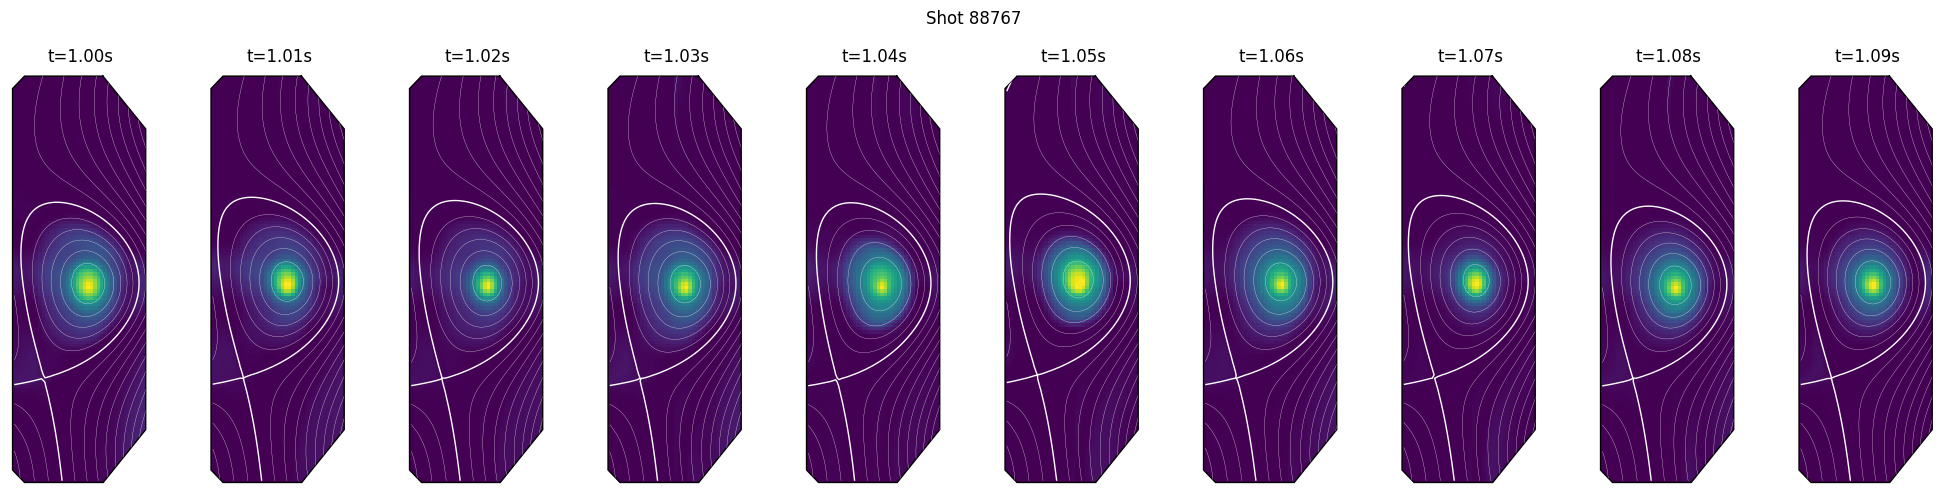

In [ ]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

psi_slice = psi[exp_idx]

summary = torch.stack([
    x_map_[0, 0].cpu() for x_map_ in im_maps[::10]
])
#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[::10]))])
show_samples(
    summary,
    titles=["t={:.2f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[::10]],
    title="Shot {}".format(shot),
    ncols=len(im_maps[::10]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[::10]],
    colorbar=False,
)

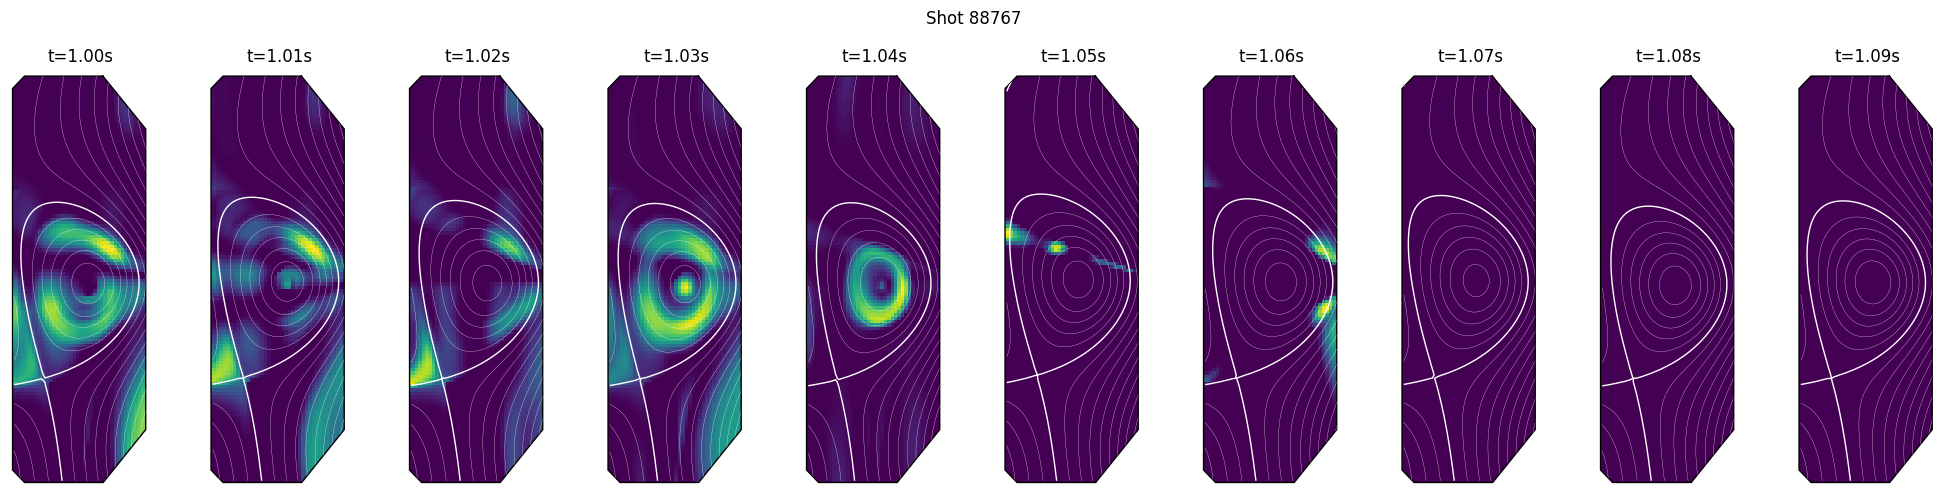

In [ ]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

psi_slice = psi[exp_idx]

summary = torch.stack([
    x_map_[0, 0].cpu() for x_map_ in im_maps[::10]
])
#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[::10]))])
show_samples(
    summary,
    titles=["t={:.2f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[::10]],
    title="Shot {}".format(shot),
    ncols=len(im_maps[::10]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[::10]],
    colorbar=False,
)

In [ ]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

plot_idxs=np.array(np.arange(35,45), dtype=int)+0

psi_slice = psi[exp_idx]

# summary = torch.stack([
#     x_map_[0, 0].cpu() for x_map_ in im_maps[plot_idxs]
# ])
summary = torch.stack([
    im_maps[i][0, 0].cpu() for i in plot_idxs
])
#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[plot_idxs]))])
show_samples(
    summary,
    titles=["t={:.3f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[plot_idxs]],
    title="Shot {}".format(shot),
    #ncols=len(im_maps[plot_idxs]),
    ncols=len([im_maps[i][0, 0].cpu() for i in plot_idxs]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[plot_idxs]],
    colorbar=False,
)

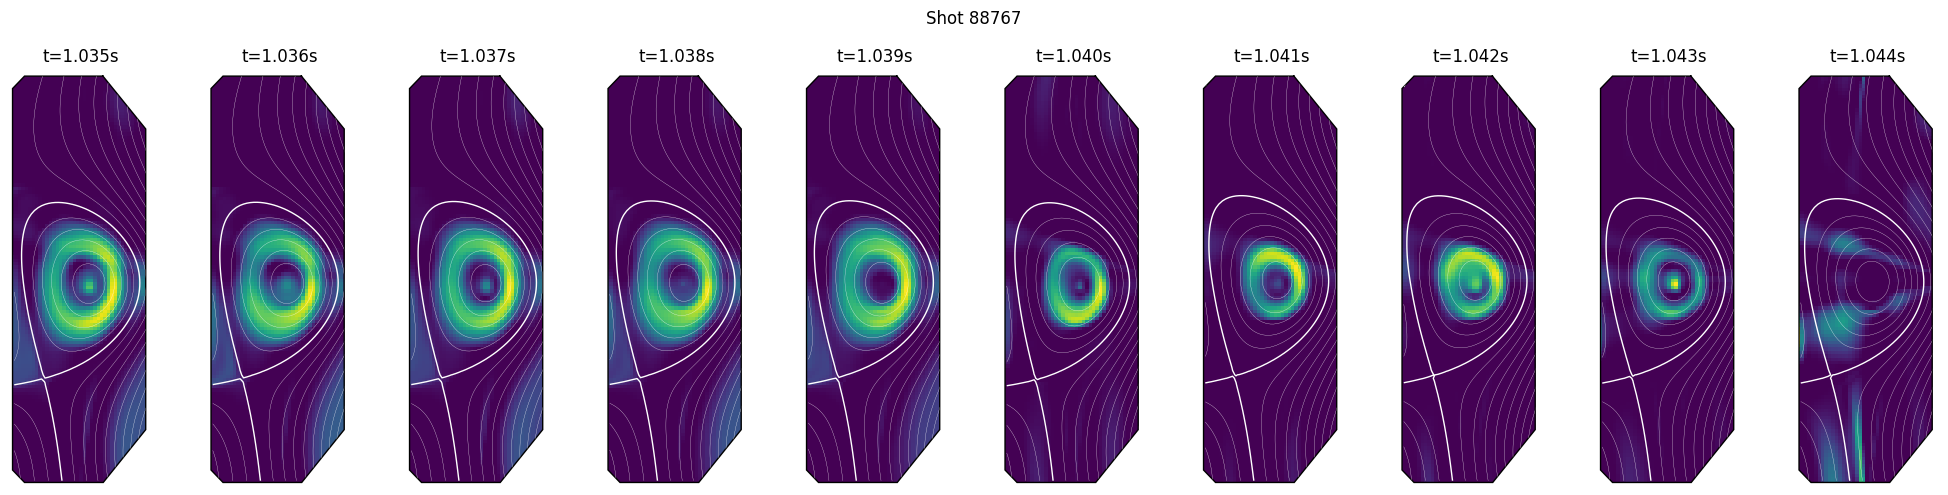

In [ ]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------

plot_idxs=np.array(np.arange(35,45), dtype=int)+0

psi_slice = psi[exp_idx]

# summary = torch.stack([
#     x_map_[0, 0].cpu() for x_map_ in im_maps[plot_idxs]
# ])
summary = torch.stack([
    im_maps[i][0, 0].cpu() for i in plot_idxs
])
#summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs)) if iidx % 2 == 0])
summary = torch.stack([summary[iidx] for iidx in range(len(exp_idxs[plot_idxs]))])
show_samples(
    summary,
    titles=["t={:.3f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[plot_idxs]],
    title="Shot {}".format(shot),
    #ncols=len(im_maps[plot_idxs]),
    ncols=len([im_maps[i][0, 0].cpu() for i in plot_idxs]),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[plot_idxs]],
    colorbar=False,
)

# Compute RD and DiffPIR inversions (background)

# Compute RD and DiffPIR inversions (fluctuations)

In [71]:
# ------------------------------
#  DiffPIR inversions (fluctuations)
# ------------------------------

# same slices as the MAP fluctuation summary plot
exp_idxs = np.arange(0, 1000)[::10]
exp_idxs = exp_idxs[exp_idxs < signal_to_invert.shape[0]]
plot_idxs = np.array(np.arange(35, 37), dtype=int)

good_channels = exp_data['good_channels'].flatten() - 1
bool_good_channels = np.zeros(y_tomo_train.shape[1], dtype=bool)
bool_good_channels[good_channels] = True

# per-channel noise measured directly from the fine time grid (frame-to-frame differences);
# background_ref subtraction leaves this noise level unchanged
noise_std_ch = np.std(np.diff(measurements, axis=0), axis=0) / np.sqrt(2)
noise_std_ch = (noise_std_ch * exp_data["etendues"].flatten() * 4 * np.pi / A_max)[good_channels]

num_samples_diffpir = 100
posterior_fluct = torch.zeros((len(plot_idxs), num_samples_diffpir, 1, H, W), dtype=torch.float32, device=device)
scaling_factors_fluct = np.zeros(len(plot_idxs))

for k, i in enumerate(plot_idxs):
    exp_idx = exp_idxs[i]

    y_tomo = np.array(signal_to_invert[exp_idx, :] * exp_data["etendues"].flatten() * 4 * np.pi) / A_max # rescale to match normalized A
    y_tomo = y_tomo[good_channels] # remove faulty channels

    scaling_factor = np.max(np.abs(y_tomo))
    scaling_factors_fluct[k] = scaling_factor
    # scalar noise level in the scaled units (rms over channels)
    sigma_y_diffpir = float(np.sqrt(np.mean((noise_std_ch / scaling_factor) ** 2)))
    print(f"t = {exp_data['measurements_times'].flatten()[exp_idx]:.3f}s | "
          f"scaling = {scaling_factor:.3e} | sigma_y = {sigma_y_diffpir:.4f}")

    posterior_fluct[k], tomo_residuals, diffusion_process = sample_posterior_diffpir(
        model=model,
        schedule=schedule,
        A=A_tomo[bool_good_channels, :],
        y=torch.from_numpy(y_tomo / scaling_factor).to(device=device, dtype=torch.float32),
        image_shape=(1, H, W),
        num_samples=num_samples_diffpir,
        num_inference_steps=250,
        zeta=0.8,
        sigma_y=sigma_y_diffpir,
        lambda_=1000,
        clip_range=None,   # fluctuations are signed: no clipping, no positivity
    )

t = 1.035s | scaling = 5.513e+10 | sigma_y = 0.0230


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

t = 1.036s | scaling = 5.385e+10 | sigma_y = 0.0236


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

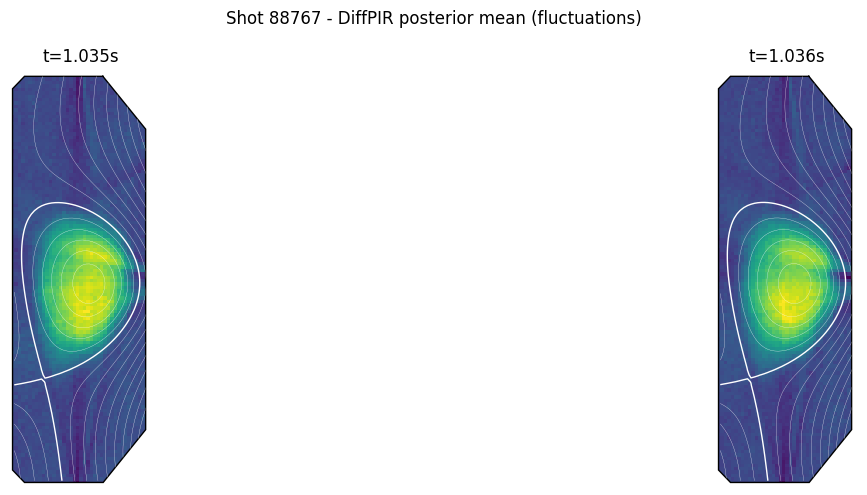

In [70]:
# ------------------------------
#  Posterior summary - DiffPIR (fluctuations)
# ------------------------------

psi_slice = psi[exp_idx]

post_mean = posterior_fluct.mean(dim=1)  # (n_slices, 1, H, W)

# back to the same units as im_maps (each slice was scaled by its own max |y|)
summary = torch.stack([
    post_mean[k, 0].cpu() * float(scaling_factors_fluct[k]) for k in range(len(plot_idxs))
])
show_samples(
    summary,
    titles=["t={:.3f}s".format(exp_data["measurements_times"].flatten()[iidx]) for iidx in exp_idxs[plot_idxs]],
    title="Shot {} - DiffPIR posterior mean (fluctuations)".format(shot),
    ncols=len(plot_idxs),
    figsize=(20, 5),
    contour_images=[psi[iidx] for iidx in exp_idxs[plot_idxs]],
    colorbar=False,
)